In [87]:
import re 

def classify_decision(text):
    #example input: '### JSON Output{  "Agreement": "DISAGREE"}'
    text = text.lower()
    # the find the strings "'agree'", "'disagree'", and "'partial'" in the text, and return the first one that is found. If none are found, return "unknown"
    if re.search(r'"agreement"\s*:\s*"agree"', text):
        return "AGREE"
    elif re.search(r'"agreement"\s*:\s*"disagree"', text):
        return "DISAGREE"
    elif re.search(r'"agreement"\s*:\s*"partial"', text):
        return "PARTIAL"
    

In [88]:
#import the client from llm.py 
from llm import Client
#import the BibParser from bib_reader.py
from bib_reader import BibParser
client = Client(model="amazon.nova-pro-v1:0")

In [83]:
import json
import pandas as pd
from tqdm import tqdm
import os

bib_files = ["bibs/"+file for file in os.listdir("bibs/") if file.endswith(".nbib")]

parser = BibParser()
bib = []
for bib_file in bib_files:
    bib_inter = parser.parse(source=bib_file)
    bib.extend(bib_inter)

title_prompt = open("title_review_prompt.txt", "r").read()
results = []
qa_prompt = open("qa_prompt.txt", "r").read()
error_count = 0
errors = []
for entry in tqdm(bib, desc="Processing entries"): 
    try:
        title = entry["TI"]
        abstract = entry["AB"]
        prompt = title_prompt.replace("[[TITLE]]", title).replace("[[ABSTRACT]]", abstract)
        response = json.loads(client.send(prompt)["response"].replace('```json',"").replace('```', "").strip())
        decision = response["Decision"]
        reasoning = response["Reasoning"]
        prompt = qa_prompt.replace("[[TITLE]]", title).replace("[[ABSTRACT]]", abstract).replace("[[DECISION]]", decision).replace("[[REASONING]]", reasoning)
        qa_response = qa_client.send(prompt)["response"].replace('```json',"").replace('```', "").strip()
        qa_response = classify_decision(qa_response)
        results.append({"title": title, "abstract": abstract, "decision": response["Decision"], "reasoning": response["Reasoning"],"source":entry["OWN"], "review": response["Is_Review"], "qa_decision": qa_response})
        error_count = 0
        errors = []
    except Exception as e:
        error_count += 1
        errors.append({"error": str(e)})
        if error_count > 5:
            print(f"Too many errors, stopping processing.")
            for error in errors:
                print(f"{error['error']}")
            break


reasoning_df = pd.DataFrame(results)




Processing entries: 100%|██████████| 711/711 [55:55<00:00,  4.72s/it]  


In [89]:
import json
import sqlite3
import pandas as pd
from tqdm import tqdm

from bib_reader import BibParser

NEW_BIB_PATH = "bibs/pubmed-LargeLangu-set(1).txt"
DB_PATH = "review.db"

# Parse only the new bib file, and screen only PMIDs not already in review.db.
new_records = BibParser().parse(NEW_BIB_PATH)

conn = sqlite3.connect(DB_PATH)
existing_pmids = {row[0] for row in conn.execute("SELECT pmid FROM papers WHERE pmid IS NOT NULL").fetchall()}
conn.close()

to_screen = [r for r in new_records if r.get("PMID") and r["PMID"] not in existing_pmids]
print(f"{len(new_records)} records in {NEW_BIB_PATH}, {len(to_screen)} not already in {DB_PATH}")

title_prompt = open("title_review_prompt.txt", "r").read()
results = []
error_count = 0
errors = []
for entry in tqdm(to_screen, desc="Screening new entries"):
    try:
        title = entry.get("TI", "")
        abstract = entry.get("AB", "")
        mesh = entry.get("MH")
        mesh_str = "; ".join(mesh) if isinstance(mesh, list) else (mesh or "")
        prompt = title_prompt.replace("[[TITLE]]", title).replace("[[ABSTRACT]]", abstract)
        response = json.loads(client.send(prompt)["response"].replace('```json', "").replace('```', "").strip())
        results.append({
            "pmid": entry["PMID"],
            "title": title,
            "abstract": abstract,
            "mesh_terms": mesh_str,
            "decision": response["Decision"],
            "reasoning": response["Reasoning"],
            "source": entry.get("OWN", "NLM"),
            "review": response.get("Is_Review"),
        })
        error_count = 0
        errors = []
    except Exception as e:
        error_count += 1
        errors.append({"pmid": entry.get("PMID"), "error": str(e)})
        if error_count > 5:
            print("Too many errors, stopping processing.")
            for error in errors:
                print(f"{error['pmid']}: {error['error']}")
            break

new_results_df = pd.DataFrame(results)
print(f"Screened {len(new_results_df)} new entries.")


610 records in bibs/pubmed-LargeLangu-set(1).txt, 265 not already in review.db


Screening new entries: 100%|██████████| 265/265 [03:53<00:00,  1.14it/s]

Screened 265 new entries.


In [90]:
import csv
from pathlib import Path

# Append to reasoning_results.csv (title, abstract, decision, reasoning, source, review, qa_decision)
# to match the existing CSV schema; qa_decision left blank since QA was skipped for this batch.
csv_path = Path("reasoning_results.csv")
csv_columns = ["title", "abstract", "decision", "reasoning", "source", "review", "qa_decision"]
write_header = not csv_path.exists()
with open(csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=csv_columns)
    if write_header:
        writer.writeheader()
    for _, row in new_results_df.iterrows():
        writer.writerow({
            "title": row["title"],
            "abstract": row["abstract"],
            "decision": row["decision"],
            "reasoning": row["reasoning"],
            "source": row["source"],
            "review": row["review"],
            "qa_decision": "",
        })

# Append to review.db with pmid/mesh_terms already populated (no migration step needed).
conn = sqlite3.connect(DB_PATH)
conn.executemany(
    """INSERT INTO papers (title, abstract, decision, reasoning, source, review, pmid, mesh_terms)
       VALUES (:title, :abstract, :decision, :reasoning, :source, :review, :pmid, :mesh_terms)""",
    new_results_df.to_dict("records"),
)
conn.commit()
conn.close()

print(f"Appended {len(new_results_df)} rows to {csv_path} and {DB_PATH}.")


Appended 265 rows to reasoning_results.csv and review.db.


decision
EXCLUDE      849
INCLUDE       70
UNCERTAIN     50
Name: count, dtype: int64

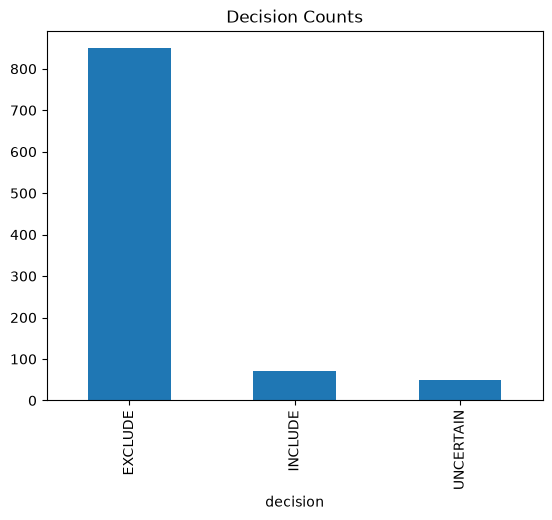

: 

In [ ]:
#load the sql database and create a report with graph of the decisions

df = pd.read_sql_query("SELECT * FROM papers", sqlite3.connect(DB_PATH))
df.value_counts("decision").plot(kind="bar", title="Decision Counts")
df.value_counts("decision")